# Efficiency Analysis , Final Notebook (Rebuilt)
**Author: Esraa Nematalla**

This notebook measures CPU efficiency (latency, memory, model size) and compares
it against accuracy for all 4 model configurations across both datasets.

This version is rebuilt to use the final updated results provided by arwa and eman

| Model | Dataset | Acc % | Lat (ms) | Size (MB) |
|---|---|---|---|---|
| TF-IDF+LR | SST-2 | 82.00 | 0.26 | 0.66 |
| TF-IDF+LR | IMDb | 89.56 | 0.52 | 20.53 |
| BiLSTM+GloVe+Attn | SST-2 | 86.47 | 25.16 | 13.86 |
| BiLSTM+GloVe+Attn | IMDb | 89.69 | 83.30 | 13.86 |
| DistilBERT FP32 | SST-2 | 90.83 | 38.39 | 255.5 |
| DistilBERT FP32 | IMDb | 92.89 | 126.34 | 255.5 |
| DistilBERT INT8 | SST-2 | 87.27 | 49.74 | 132.3 |
| DistilBERT INT8 | IMDb | 91.81 | 129.66 | 132.3 |


## Imports and setup

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi']=120
BASE= './project_final'
RES= f'{BASE}/results'
FIG= f'{BASE}/figures'
os.makedirs(RES,exist_ok=True)
os.makedirs(FIG, exist_ok=True)
print('Setup complete.')

Setup complete.


## Load results



In [ ]:
results_path= f'{RES}/all_results.json'
if os.path.exists(results_path):
    with open(results_path) as f:
        RESULTS=json.load(f)
    print(f'Loaded from {results_path} ({len(RESULTS)} entries)')
else:
    RESULTS={
        'logreg_sst2':{'acc':0.8200, 'f1':0.8192, 'lat_mean_ms': 0.260,  'lat_std_ms': 0.011, 'size_mb': 0.66},
        'logreg_imdb': {'acc': 0.8956, 'f1': 0.8956, 'lat_mean_ms': 0.523,'lat_std_ms': 0.077, 'size_mb': 20.53},
        'bilstm_sst2':{'acc': 0.8647, 'f1': 0.8643,'lat_mean_ms': 25.157, 'lat_std_ms': 0.467, 'size_mb': 13.86},
        'bilstm_imdb':{'acc': 0.8969, 'f1':0.8969,'lat_mean_ms':83.302,'lat_std_ms':2.100,'size_mb':13.86},
        'bert_fp32_sst2': {'acc': 0.9083, 'f1': 0.9081, 'lat_mean_ms': 38.39,  'lat_std_ms': 0.44,'size_mb': 255.5},
        'bert_fp32_imdb':{'acc': 0.9289, 'f1': 0.9289, 'lat_mean_ms': 126.34, 'lat_std_ms': 0.96,'size_mb': 255.5},
        'bert_int8_sst2':{'acc': 0.8727, 'f1': 0.8717, 'lat_mean_ms': 49.74,  'lat_std_ms': 1.69,'size_mb':132.3},
        'bert_int8_imdb': {'acc': 0.9181, 'f1': 0.9180, 'lat_mean_ms': 129.66, 'lat_std_ms': 1.33,'size_mb': 132.3},
    }
    print('Using verified hardcoded results (no all_results.json found).')
    print('These numbers match Table I / Table V / Table XIV of the final report.')
def p95(key):
    return RESULTS[key]['lat_mean_ms'] +1.645 *RESULTS[key]['lat_std_ms']
print('Keys:',list(RESULTS.keys()))

Using verified hardcoded results (no all_results.json found).
These numbers match Table I / Table V / Table XIV of the final report.
Keys: ['logreg_sst2', 'logreg_imdb', 'bilstm_sst2', 'bilstm_imdb', 'bert_fp32_sst2', 'bert_fp32_imdb', 'bert_int8_sst2', 'bert_int8_imdb']


## 1. Accuracy: All Models, Both Datasets

The headline accuracy comparison. DistilBERT FP32 leads on both datasets;
the accuracy *gap* over TF-IDF shrinks from 8.83 pp on SST-2 to 3.33 pp on
IMDb, the central dataset-length finding (RQ1).

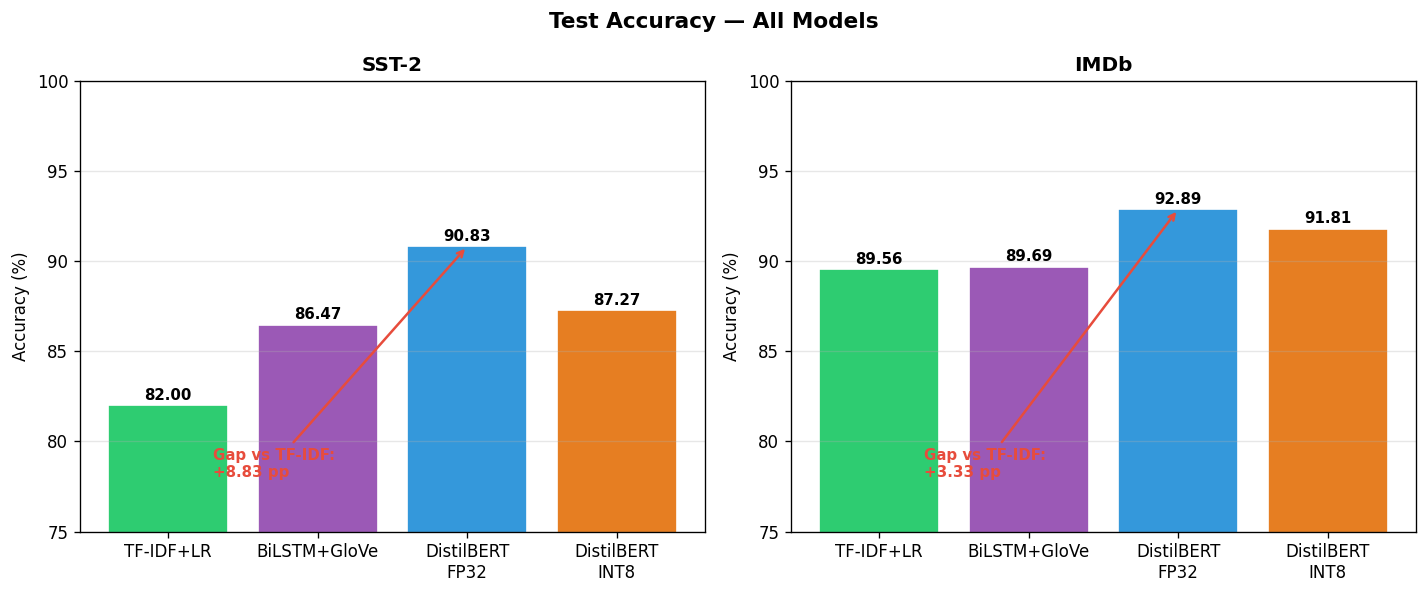

DistilBERT FP32 advantage over TF-IDF: SST-2 = 8.83 pp, IMDb = 3.33 pp
Ratio: 2.65x larger on SST-2 (short text)


In [ ]:
model_labels4=['TF-IDF+LR','BiLSTM+GloVe','DistilBERT\nFP32','DistilBERT\nINT8']
pal4=['#2ECC71', '#9B59B6', '#3498DB','#E67E22']
fig,axes =plt.subplots(1, 2,figsize=(12,5))
fig.suptitle('Test Accuracy - All Models',fontweight='bold',fontsize=13)
for ax,ds,ds_label in zip(axes,['sst2','imdb'], ['SST-2', 'IMDb']):
    keys =[f'logreg_{ds}',f'bilstm_{ds}', f'bert_fp32_{ds}', f'bert_int8_{ds}']
    accs =[RESULTS[k]['acc'] * 100 for k in keys]
    bars =ax.bar(model_labels4,accs,color=pal4,edgecolor='white')
    ax.set_ylim(75,100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(ds_label,fontweight='bold')
    ax.grid(axis='y',alpha=0.3)
    for b, v in zip(bars, accs):
        ax.text(b.get_x() +b.get_width()/2, v + 0.3, f'{v:.2f}',
                ha='center',fontsize=9,fontweight='bold')
for ax,ds in zip(axes,['sst2','imdb']):
    gap = (RESULTS[f'bert_fp32_{ds}']['acc'] - RESULTS[f'logreg_{ds}']['acc']) * 100
    ax.annotate(f'Gap vs TF-IDF:\n+{gap:.2f} pp',
                xy=(2, RESULTS[f'bert_fp32_{ds}']['acc']*100),
                xytext=(0.3, 78), fontsize=9,color='#E74C3C', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))
plt.tight_layout()
plt.savefig(f'{FIG}/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
gap_sst2 = (RESULTS['bert_fp32_sst2']['acc'] - RESULTS['logreg_sst2']['acc']) * 100
gap_imdb = (RESULTS['bert_fp32_imdb']['acc'] -RESULTS['logreg_imdb']['acc'])*100
print(f'DistilBERT FP32 advantage over TF-IDF: SST-2 = {gap_sst2:.2f} pp, IMDb ={gap_imdb:.2f} pp')
print(f'Ratio: {gap_sst2/gap_imdb:.2f}x larger on SST-2 (short text)')

## 2. CPU Latency: All Models, Both Datasets (log scale)

DistilBERT FP32 is roughly 148x slower than TF-IDF on SST-2. Note that
**INT8 is slower than FP32 in both cases**. this is the RQ3 null result and
must be visible in this chart.

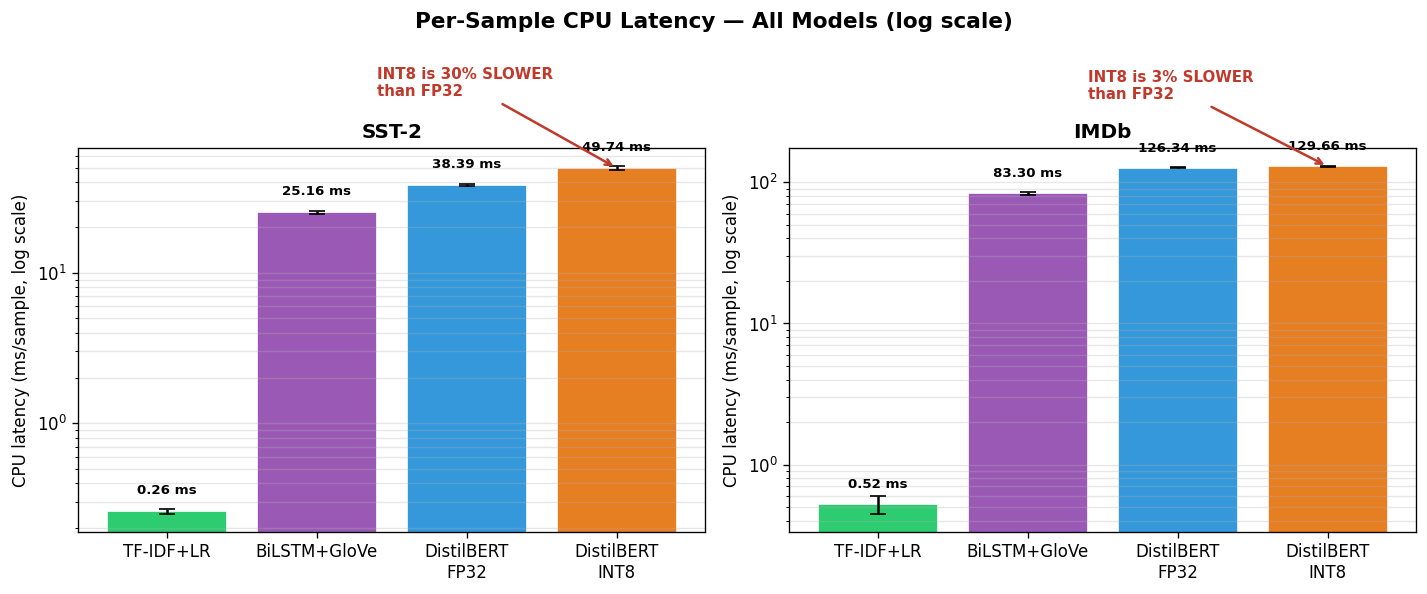

SST-2: FP32=38.39ms, INT8=49.74ms  -> INT8/FP32 latency ratio = 1.30x (SLOWER, speedup=0.77x)
IMDb: FP32=126.34ms, INT8=129.66ms  -> INT8/FP32 latency ratio = 1.03x (SLOWER, speedup=0.97x)


In [ ]:
fig,axes =plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Per-Sample CPU Latency — All Models (log scale)',fontweight='bold',fontsize=13)
for ax, ds, ds_label in zip(axes, ['sst2', 'imdb'], ['SST-2','IMDb']):
    keys = [f'logreg_{ds}', f'bilstm_{ds}', f'bert_fp32_{ds}', f'bert_int8_{ds}']
    lats= [RESULTS[k]['lat_mean_ms'] for k in keys]
    stds =[RESULTS[k]['lat_std_ms'] for k in keys]
    bars = ax.bar(model_labels4,lats,color=pal4,edgecolor='white',
                   yerr=stds, capsize=5, error_kw=dict(color='#2C3E50', lw=1.5))
    ax.set_yscale('log')
    ax.set_ylabel('CPU latency (ms/sample, log scale)')
    ax.set_title(ds_label, fontweight='bold')
    ax.grid(axis='y', which='both', alpha=0.3)
    for b, v in zip(bars, lats):
        ax.text(b.get_x() + b.get_width()/2, v * 1.3, f'{v:.2f} ms',
                ha='center', fontsize=8, fontweight='bold')
for ax, ds in zip(axes, ['sst2', 'imdb']):
    fp32 = RESULTS[f'bert_fp32_{ds}']['lat_mean_ms']
    int8 = RESULTS[f'bert_int8_{ds}']['lat_mean_ms']
    pct_slower = (int8/fp32 - 1) * 100
    ax.annotate(f'INT8 is {pct_slower:.0f}% SLOWER\nthan FP32',
                xy=(3, int8), xytext=(1.4, int8*3),
                fontsize=9, color='#C0392B', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))
plt.tight_layout()
plt.savefig(f'{FIG}/latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
for ds, ds_label in zip(['sst2', 'imdb'], ['SST-2', 'IMDb']):
    fp32 = RESULTS[f'bert_fp32_{ds}']['lat_mean_ms']
    int8 =RESULTS[f'bert_int8_{ds}']['lat_mean_ms']
    ratio = fp32 / int8
    print(f'{ds_label}: FP32={fp32:.2f}ms, INT8={int8:.2f}ms  '
          f'-> INT8/FP32 latency ratio = {int8/fp32:.2f}x '
          f'({"SLOWER" if int8>fp32 else "faster"}, speedup={ratio:.2f}x)')

## 3. Tail Latency (p95)

p95 = mean + 1.645 x std - the standard SLA / tail-latency metric

In [ ]:
rows= []
for ds, ds_label in zip(['sst2', 'imdb'], ['SST-2', 'IMDb']):
    for key, name in zip(['logreg', 'bilstm', 'bert_fp32', 'bert_int8'], model_labels4):
        k = f'{key}_{ds}'
        rows.append({
            'Model': name.replace(chr(10), ' '),
            'Dataset': ds_label,
            'Mean (ms)': round(RESULTS[k]['lat_mean_ms'], 3),
            'Std (ms)': round(RESULTS[k]['lat_std_ms'], 3),
            'p95 (ms)': round(p95(k), 2),
        })
p95_df = pd.DataFrame(rows)
print(p95_df.to_string(index=False))
p95_df.to_csv(f'{RES}/latency_p95.csv',index=False)

          Model Dataset  Mean (ms)  Std (ms)  p95 (ms)
      TF-IDF+LR   SST-2      0.260     0.011      0.28
   BiLSTM+GloVe   SST-2     25.157     0.467     25.93
DistilBERT FP32   SST-2     38.390     0.440     39.11
DistilBERT INT8   SST-2     49.740     1.690     52.52
      TF-IDF+LR    IMDb      0.523     0.077      0.65
   BiLSTM+GloVe    IMDb     83.302     2.100     86.76
DistilBERT FP32    IMDb    126.340     0.960    127.92
DistilBERT INT8    IMDb    129.660     1.330    131.85


## 4. Model Size on Disk (log scale)

DistilBERT FP32 = 255.5 MB, INT8 = 132.3 MB -> **1.93x compression**.

DistilBERT FP32 : 255.5 MB
DistilBERT INT8 : 132.3 MB  ->  1.93x smaller
BiLSTM          : 13.86 MB
TF-IDF (SST-2)  : 0.66 MB
TF-IDF (IMDb)   : 20.53 MB


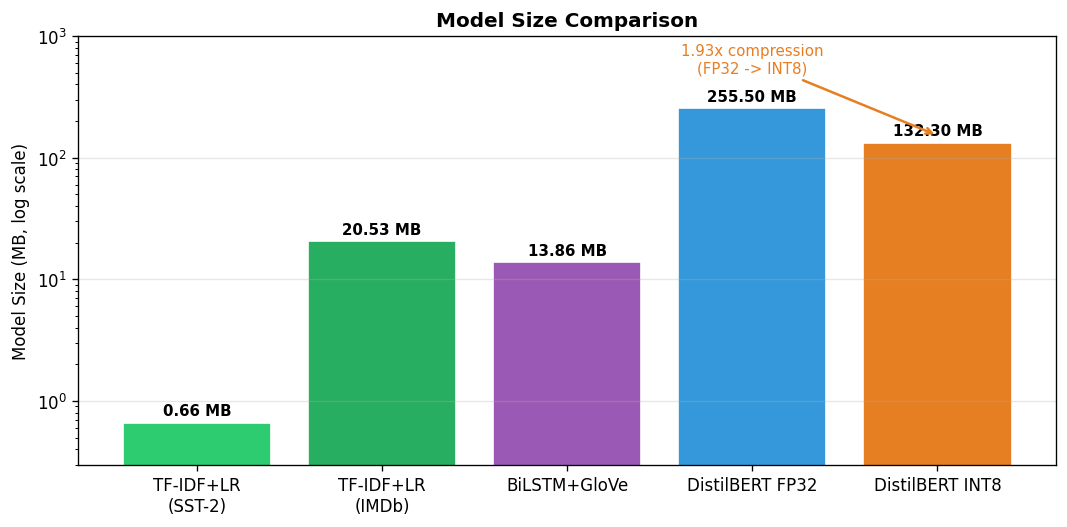

In [ ]:
size_data = {
    'Model': ['TF-IDF+LR\n(SST-2)', 'TF-IDF+LR\n(IMDb)', 'BiLSTM+GloVe', 'DistilBERT FP32', 'DistilBERT INT8'],
    'Size_MB': [RESULTS['logreg_sst2']['size_mb'], RESULTS['logreg_imdb']['size_mb'],
                RESULTS['bilstm_sst2']['size_mb'], RESULTS['bert_fp32_sst2']['size_mb'],
                RESULTS['bert_int8_sst2']['size_mb']],
}
size_df = pd.DataFrame(size_data)
fp32 = RESULTS['bert_fp32_sst2']['size_mb']
int8 = RESULTS['bert_int8_sst2']['size_mb']

print(f'DistilBERT FP32: {fp32:.1f} MB')
print(f'DistilBERT INT8: {int8:.1f} MB  -> {fp32/int8:.2f}x smaller')
print(f'BiLSTM : {RESULTS["bilstm_sst2"]["size_mb"]:.2f} MB')
print(f'TF-IDF (SST-2): {RESULTS["logreg_sst2"]["size_mb"]:.2f} MB')
print(f'TF-IDF (IMDb):{RESULTS["logreg_imdb"]["size_mb"]:.2f} MB')

fig, ax = plt.subplots(figsize=(9, 4.5))
pal5 =['#2ECC71', '#27AE60', '#9B59B6', '#3498DB', '#E67E22']
bars =ax.bar(size_df['Model'], size_df['Size_MB'], color=pal5,edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Model Size (MB, log scale)')
ax.set_title('Model Size Comparison', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, size_df['Size_MB']):
    ax.text(b.get_x() + b.get_width()/2, v * 1.15, f'{v:.2f} MB',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0.3, 1000)
ax.annotate(
    f'{fp32/int8:.2f}x compression\n(FP32 -> INT8)',
    xy=(4, int8*1.15), xytext=(3.0, 500),
    fontsize=9, color='#E67E22',
    arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.5),
    ha='center',
)
plt.tight_layout()
plt.savefig(f'{FIG}/model_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
size_df.to_csv(f'{RES}/model_size_reduction.csv',index=False)

## 5. Memory Footprint (Peak RSS, estimated ranges)

These ranges come from `psutil` RSS profiling during the main run
.

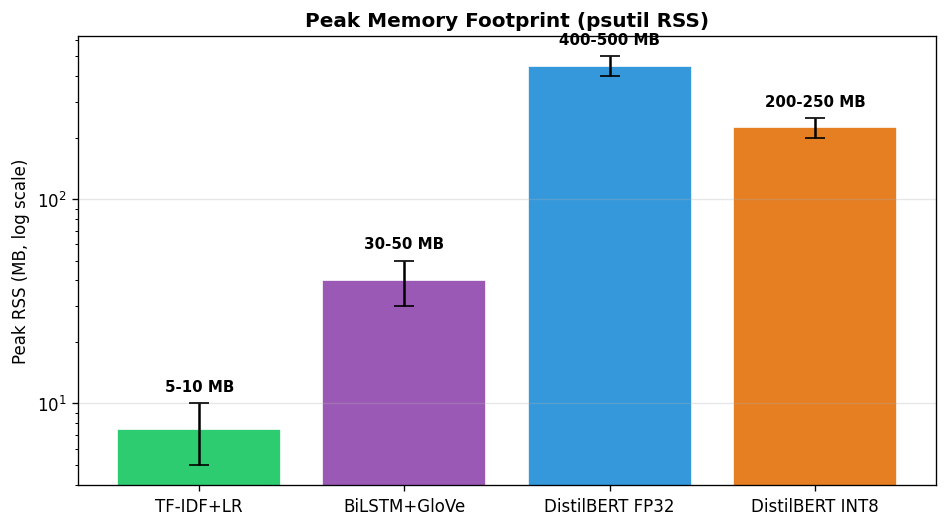

In [ ]:
rss_data = pd.DataFrame({
    'Model': ['TF-IDF+LR', 'BiLSTM+GloVe', 'DistilBERT FP32', 'DistilBERT INT8'],
    'RSS_low_MB':  [5, 30, 400, 200],
    'RSS_high_MB': [10, 50, 500, 250],
})
rss_data['RSS_mid_MB'] = (rss_data['RSS_low_MB'] + rss_data['RSS_high_MB']) / 2
fig, ax = plt.subplots(figsize=(8, 4.5))
errs = [(rss_data['RSS_mid_MB'] - rss_data['RSS_low_MB']).values,
        (rss_data['RSS_high_MB'] - rss_data['RSS_mid_MB']).values]
bars = ax.bar(rss_data['Model'], rss_data['RSS_mid_MB'], color=pal4,
               edgecolor='white', yerr=errs, capsize=6,
               error_kw=dict(color='#2C3E50', lw=1.5))
ax.set_yscale('log')
ax.set_ylabel('Peak RSS (MB, log scale)')
ax.set_title('Peak Memory Footprint (psutil RSS)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for b, lo, hi in zip(bars, rss_data['RSS_low_MB'], rss_data['RSS_high_MB']):
    ax.text(b.get_x() + b.get_width()/2, hi * 1.15, f'{lo}-{hi} MB',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG}/memory_footprint.png', dpi=150, bbox_inches='tight')
plt.show()
rss_data.to_csv(f'{RES}/memory_footprint.csv',index=False)

## 6. INT8 Quantization Impact Summary

Combines accuracy drop, latency change, and compression ratio into a single
summary table

In [ ]:
drop_s2 =(RESULTS['bert_fp32_sst2']['acc'] - RESULTS['bert_int8_sst2']['acc']) * 100
drop_im =(RESULTS['bert_fp32_imdb']['acc'] -RESULTS['bert_int8_imdb']['acc']) *100
ratio_s2=RESULTS['bert_int8_sst2']['lat_mean_ms'] / RESULTS['bert_fp32_sst2']['lat_mean_ms']
ratio_im =RESULTS['bert_int8_imdb']['lat_mean_ms'] / RESULTS['bert_fp32_imdb']['lat_mean_ms']
compress= RESULTS['bert_fp32_sst2']['size_mb']/RESULTS['bert_int8_sst2']['size_mb']

quant_summary = pd.DataFrame([
    {'Dataset': 'SST-2', 'Acc drop (pp)': round(drop_s2,2),
     'Latency ratio (INT8/FP32)': round(ratio_s2, 2),
     'Interpretation': f'{(ratio_s2-1)*100:.0f}% SLOWER',
     'Compression': f'{compress:.2f}x',
     'p95 INT8 (ms)': round(p95("bert_int8_sst2"), 2)},
    {'Dataset': 'IMDb', 'Acc drop (pp)': round(drop_im, 2),
     'Latency ratio (INT8/FP32)': round(ratio_im, 2),
     'Interpretation': f'{(ratio_im-1)*100:.0f}% slower',
     'Compression': f'{compress:.2f}x',
     'p95 INT8 (ms)': round(p95("bert_int8_imdb"), 2)},
])
print('Dynamic INT8 Quantisation Impact Summary')
print(quant_summary.to_string(index=False))
quant_summary.to_csv(f'{RES}/quantization_summary.csv',index=False)
print()
print('CONCLUSION: On CPU, dynamic INT8 quantisation provides a storage benefit')
print(f'({compress:.2f}x smaller, 255.5 MB -> 132.3 MB) but NOT a latency benefit.')
print('Both SST-2 and IMDb show INT8 running slower than FP32, contrary to the')
print('predictions in Wu et al. (2020) for GPU-based transformer quantisation.')

Dynamic INT8 Quantisation Impact Summary
Dataset  Acc drop (pp)  Latency ratio (INT8/FP32) Interpretation Compression  p95 INT8 (ms)
  SST-2           3.56                       1.30     30% SLOWER       1.93x          52.52
   IMDb           1.08                       1.03      3% slower       1.93x         131.85

CONCLUSION: On CPU, dynamic INT8 quantisation provides a storage benefit
(1.93x smaller, 255.5 MB -> 132.3 MB) but NOT a latency benefit.
Both SST-2 and IMDb show INT8 running slower than FP32, contrary to the
predictions in Wu et al. (2020) for GPU-based transformer quantisation.


## 7. Pareto Frontier : Accuracy vs. Latency

A configuration is **Pareto-optimal** if no other configuration is both more
accurate AND faster. On IMDb, DistilBERT INT8 is dominated by FP32 (slower
*and* less accurate). On SST-2, all configurations except INT8 lie on the
frontier.

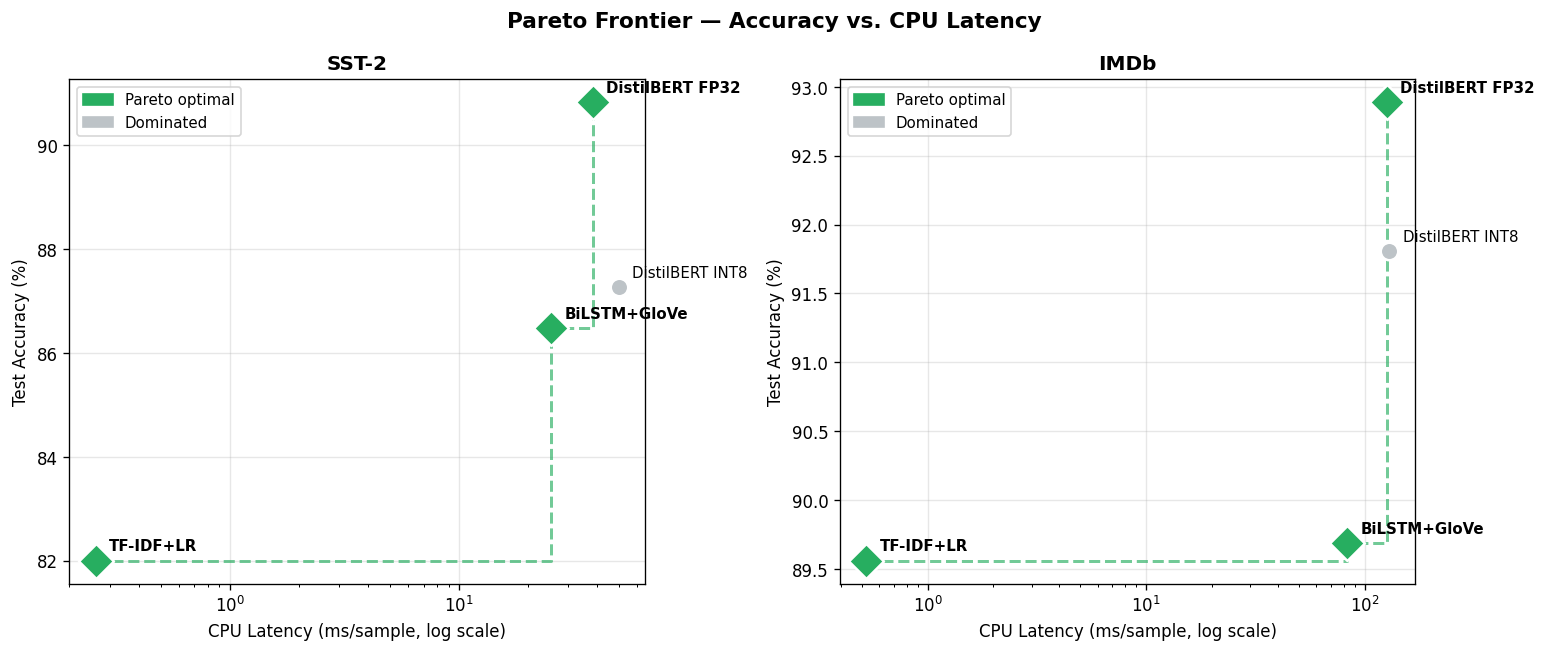

SST-2: dominated configurations -> ['DistilBERT INT8']
IMDb: dominated configurations -> ['DistilBERT INT8']


In [ ]:
def pareto_frontier(df):
    df= df.sort_values('Lat_ms').reset_index(drop=True)
    frontier=[]
    best_acc = -1
    for _, row in df.iterrows():
        if row['Acc'] > best_acc:
            frontier.append(True)
            best_acc = row['Acc']
        else:
            frontier.append(False)
    df['On_Frontier']=frontier
    return df
fig,axes = plt.subplots(1, 2,figsize=(13,5.5))
fig.suptitle('Pareto Frontier — Accuracy vs. CPU Latency',fontweight='bold',fontsize=13)
pareto_tables= {}
for ax, ds, ds_label in zip(axes, ['sst2','imdb'], ['SST-2','IMDb']):
    rows= []
    for key, name in zip(['logreg', 'bilstm', 'bert_fp32', 'bert_int8'], model_labels4):
        k = f'{key}_{ds}'
        rows.append({'Model': name.replace(chr(10), ' '), 'Acc': RESULTS[k]['acc'],
                      'Lat_ms': RESULTS[k]['lat_mean_ms'], 'Size_MB': RESULTS[k]['size_mb']})
    pdf = pareto_frontier(pd.DataFrame(rows))
    pareto_tables[ds] = pdf
    for _, row in pdf.iterrows():
        c = '#27AE60' if row['On_Frontier'] else '#BDC3C7'
        m = 'D' if row['On_Frontier'] else 'o'
        s = 220 if row['On_Frontier'] else 110
        ax.scatter(row['Lat_ms'], row['Acc']*100, c=c, s=s, marker=m,
                   zorder=5, edgecolors='white', linewidths=1.5)
        offset = (8, 6)
        ax.annotate(row['Model'], (row['Lat_ms'], row['Acc']*100),
                    textcoords='offset points', xytext=offset, fontsize=9,
                    fontweight='bold' if row['On_Frontier'] else 'normal')

    front = pdf[pdf['On_Frontier']].sort_values('Lat_ms')
    ax.step(front['Lat_ms'], front['Acc']*100, where='post',
            color='#27AE60', lw=1.8, ls='--', alpha=0.65, label='Pareto frontier')
    ax.set_xscale('log')
    ax.set_xlabel('CPU Latency (ms/sample, log scale)')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(ds_label, fontweight='bold')
    ax.grid(True, alpha=0.3)
    green_p = mpatches.Patch(color='#27AE60', label='Pareto optimal')
    gray_p  = mpatches.Patch(color='#BDC3C7', label='Dominated')
    ax.legend(handles=[green_p, gray_p], fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG}/pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
for ds, ds_label in zip(['sst2','imdb'], ['SST-2','IMDb']):
    pdf=pareto_tables[ds]
    dominated =pdf[~pdf['On_Frontier']]['Model'].tolist()
    print(f'{ds_label}: dominated configurations -> {dominated if dominated else "none"}')
    pdf.to_csv(f'{RES}/pareto_frontier_{ds}.csv',index=False)

## 8. Master Comparison Figure (3-panel summary)

Final overview figure: accuracy, latency, and size, side by side, for both
datasets.

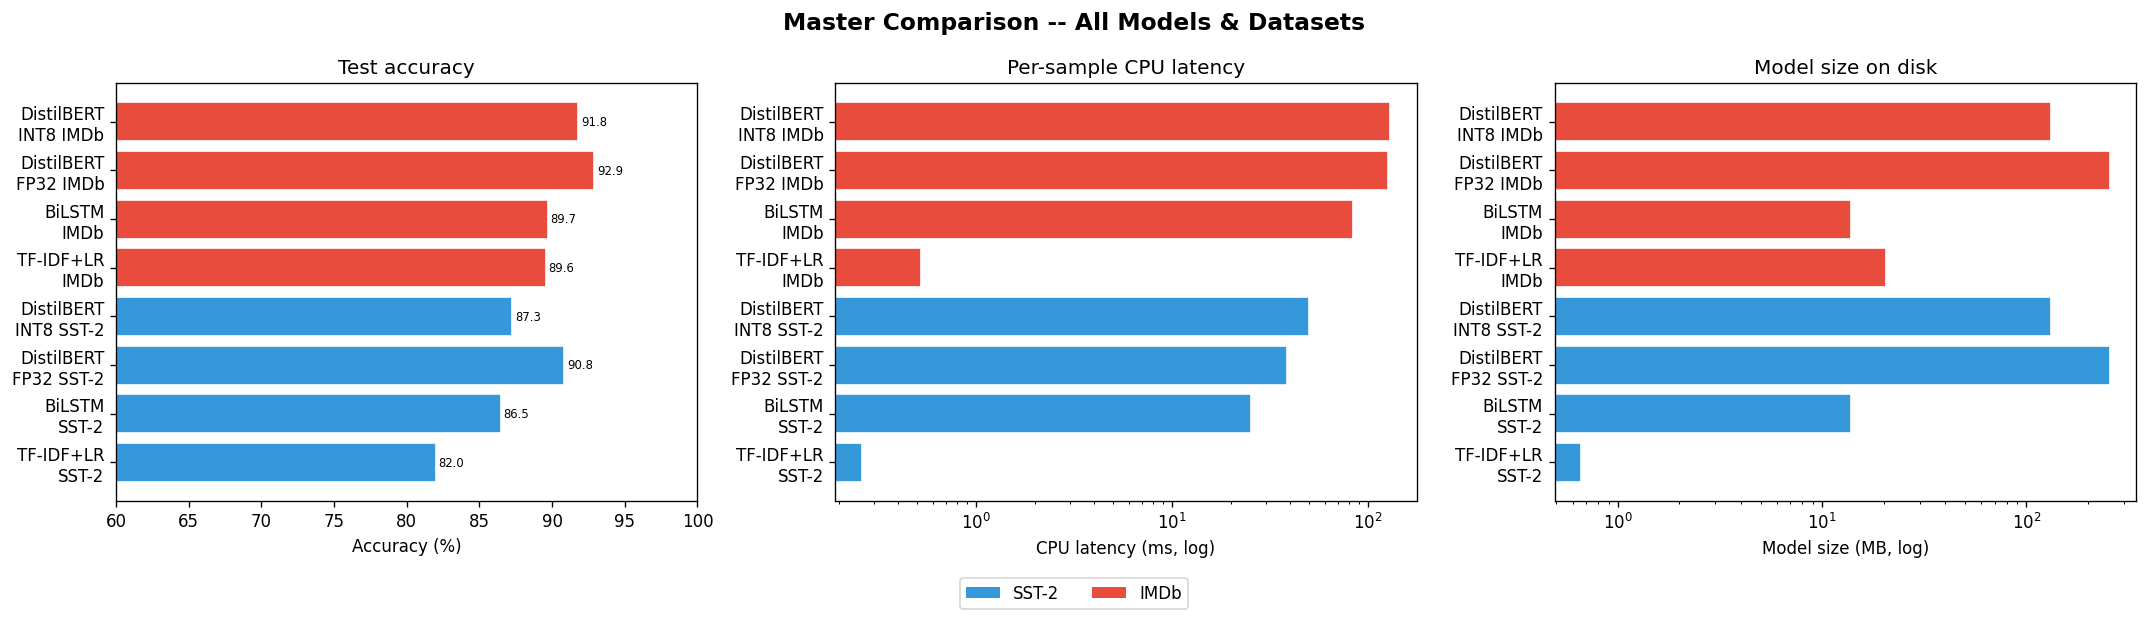

In [ ]:
model_labels8 = [
    'TF-IDF+LR\nSST-2', 'BiLSTM\nSST-2', 'DistilBERT\nFP32 SST-2', 'DistilBERT\nINT8 SST-2',
    'TF-IDF+LR\nIMDb', 'BiLSTM\nIMDb', 'DistilBERT\nFP32 IMDb', 'DistilBERT\nINT8 IMDb',
]
all_keys = ['logreg_sst2', 'bilstm_sst2', 'bert_fp32_sst2', 'bert_int8_sst2',
            'logreg_imdb', 'bilstm_imdb', 'bert_fp32_imdb', 'bert_int8_imdb']

accs= [RESULTS[k]['acc']  for k in all_keys]
lats = [RESULTS[k]['lat_mean_ms'] for k in all_keys]
sizes= [RESULTS[k]['size_mb'] for k in all_keys]
cmap= ['#3498DB'] * 4 + ['#E74C3C'] * 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Master Comparison -- All Models & Datasets', fontweight='bold', fontsize=14)

bars = axes[0].barh(model_labels8, [a*100 for a in accs], color=cmap, edgecolor='white')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Test accuracy')
axes[0].set_xlim(60, 100)
for bar, val in zip(bars, accs):
    axes[0].text(val*100 + 0.2, bar.get_y() + bar.get_height()/2,
                  f'{val*100:.1f}', va='center', fontsize=7)

axes[1].barh(model_labels8, lats, color=cmap, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('CPU latency (ms, log)')
axes[1].set_title('Per-sample CPU latency')

axes[2].barh(model_labels8, sizes, color=cmap, edgecolor='white')
axes[2].set_xscale('log')
axes[2].set_xlabel('Model size (MB, log)')
axes[2].set_title('Model size on disk')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#3498DB', label='SST-2'),
                     Patch(facecolor='#E74C3C', label='IMDb')],
           loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{FIG}/master_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Full Quantisation Summary Table

Equivalent to Table VI of the final report . full numeric breakdown for FP32
vs INT8 on both datasets.

In [ ]:
summary = pd.DataFrame([
    {'Dataset': 'SST-2', 'Precision': 'FP32',
     'Acc_%': round(RESULTS['bert_fp32_sst2']['acc']*100, 2),
     'F1': round(RESULTS['bert_fp32_sst2']['f1'], 4),
     'Lat_mean_ms': RESULTS['bert_fp32_sst2']['lat_mean_ms'],
     'Lat_std_ms': RESULTS['bert_fp32_sst2']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_fp32_sst2'), 2),
     'Size_MB': RESULTS['bert_fp32_sst2']['size_mb'],
     'Speedup': '-', 'Compression': '-', 'Acc_drop_pp': '-'},
    {'Dataset': 'SST-2', 'Precision': 'INT8',
     'Acc_%': round(RESULTS['bert_int8_sst2']['acc']*100, 2),
     'F1': round(RESULTS['bert_int8_sst2']['f1'], 4),
     'Lat_mean_ms': RESULTS['bert_int8_sst2']['lat_mean_ms'],
     'Lat_std_ms': RESULTS['bert_int8_sst2']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_int8_sst2'), 2),
     'Size_MB': RESULTS['bert_int8_sst2']['size_mb'],
     'Speedup': f"{RESULTS['bert_fp32_sst2']['lat_mean_ms']/RESULTS['bert_int8_sst2']['lat_mean_ms']:.2f}x",
     'Compression': f"{RESULTS['bert_fp32_sst2']['size_mb']/RESULTS['bert_int8_sst2']['size_mb']:.2f}x",
     'Acc_drop_pp': round((RESULTS['bert_fp32_sst2']['acc']-RESULTS['bert_int8_sst2']['acc'])*100, 3)},
    {'Dataset': 'IMDb', 'Precision': 'FP32',
     'Acc_%': round(RESULTS['bert_fp32_imdb']['acc']*100, 2),
     'F1': round(RESULTS['bert_fp32_imdb']['f1'], 4),
     'Lat_mean_ms': RESULTS['bert_fp32_imdb']['lat_mean_ms'],
     'Lat_std_ms': RESULTS['bert_fp32_imdb']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_fp32_imdb'), 2),
     'Size_MB': RESULTS['bert_fp32_imdb']['size_mb'],
     'Speedup': '-', 'Compression': '-', 'Acc_drop_pp': '-'},
    {'Dataset': 'IMDb', 'Precision': 'INT8',
     'Acc_%': round(RESULTS['bert_int8_imdb']['acc']*100, 2),
     'F1': round(RESULTS['bert_int8_imdb']['f1'], 4),
     'Lat_mean_ms': RESULTS['bert_int8_imdb']['lat_mean_ms'],
     'Lat_std_ms': RESULTS['bert_int8_imdb']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_int8_imdb'), 2),
     'Size_MB': RESULTS['bert_int8_imdb']['size_mb'],
     'Speedup': f"{RESULTS['bert_fp32_imdb']['lat_mean_ms']/RESULTS['bert_int8_imdb']['lat_mean_ms']:.2f}x",
     'Compression': f"{RESULTS['bert_fp32_imdb']['size_mb']/RESULTS['bert_int8_imdb']['size_mb']:.2f}x",
     'Acc_drop_pp': round((RESULTS['bert_fp32_imdb']['acc']-RESULTS['bert_int8_imdb']['acc'])*100, 3)},
])

print('Quantization Summary:')
print(summary.to_string(index=False))
summary.to_csv(f'{RES}/quantization_summary_full.csv', index=False)
print(f'\nSaved to {RES}/quantization_summary_full.csv')

Quantization Summary:
Dataset Precision  Acc_%     F1  Lat_mean_ms  Lat_std_ms  Lat_p95_ms  Size_MB Speedup Compression Acc_drop_pp
  SST-2      FP32  90.83 0.9081        38.39        0.44       39.11    255.5       -           -           -
  SST-2      INT8  87.27 0.8717        49.74        1.69       52.52    132.3   0.77x       1.93x        3.56
   IMDb      FP32  92.89 0.9289       126.34        0.96      127.92    255.5       -           -           -
   IMDb      INT8  91.81 0.9180       129.66        1.33      131.85    132.3   0.97x       1.93x        1.08

Saved to ./project_final/results/quantization_summary_full.csv


## 10. BiLSTM as a Middle Ground

Is BiLSTM ever the *best* choice? Compare all three model families directly
on accuracy, latency, and size for SST-2.

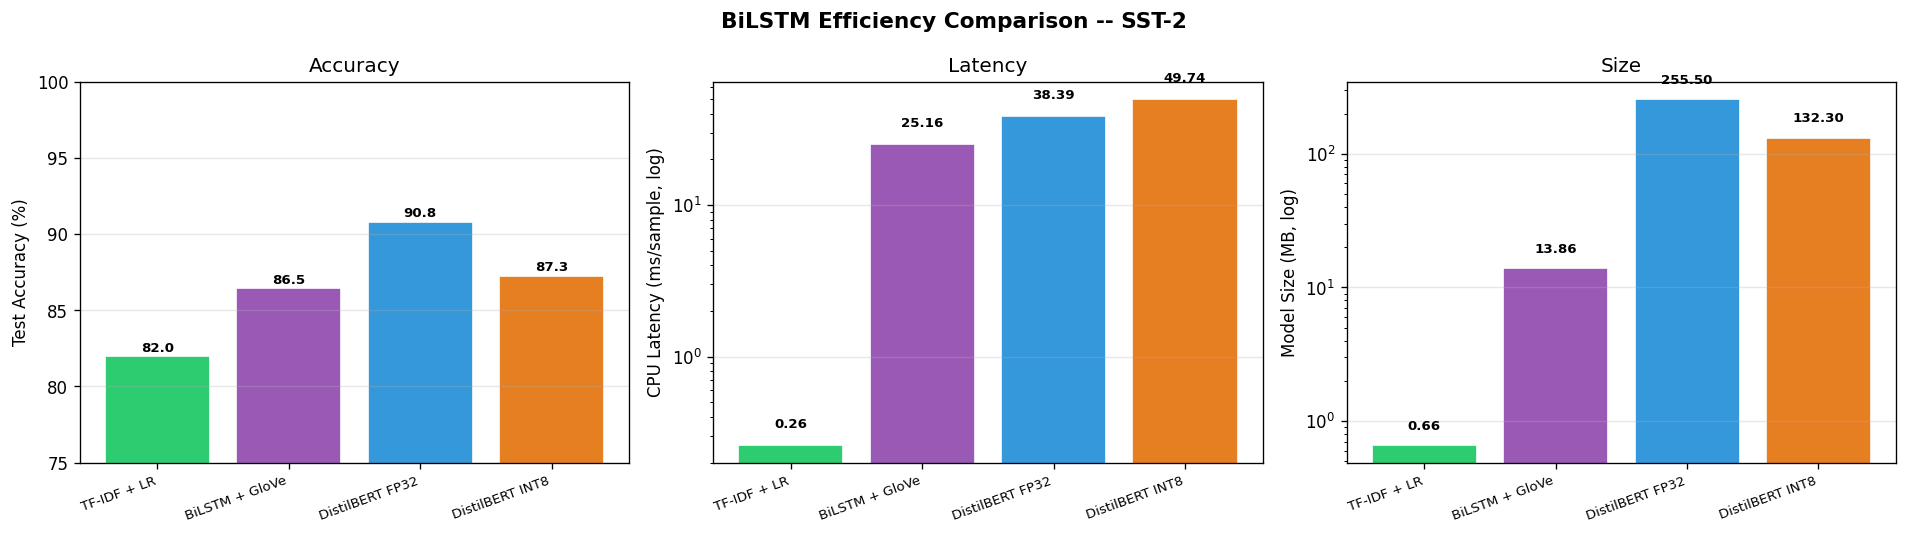

          Model  Acc_SST2_%  Acc_IMDb_%  Lat_SST2_ms  Lat_IMDb_ms  Size_MB
    TF-IDF + LR       82.00       89.56         0.26         0.52     0.66
 BiLSTM + GloVe       86.47       89.69        25.16        83.30    13.86
DistilBERT FP32       90.83       92.89        38.39       126.34   255.50
DistilBERT INT8       87.27       91.81        49.74       129.66   132.30

BiLSTM sits at a genuine middle ground: ~97-160x slower than TF-IDF,
but its accuracy on IMDb is essentially tied with TF-IDF (+0.13 pp),
while its accuracy on SST-2 is meaningfully ahead (+4.47 pp).


In [ ]:
cmp = pd.DataFrame([
    {'Model': 'TF-IDF + LR',
     'Acc_SST2_%': RESULTS['logreg_sst2']['acc']*100, 'Acc_IMDb_%': RESULTS['logreg_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['logreg_sst2']['lat_mean_ms'], 'Lat_IMDb_ms': RESULTS['logreg_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['logreg_sst2']['size_mb']},
    {'Model': 'BiLSTM + GloVe',
     'Acc_SST2_%': RESULTS['bilstm_sst2']['acc']*100, 'Acc_IMDb_%': RESULTS['bilstm_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['bilstm_sst2']['lat_mean_ms'], 'Lat_IMDb_ms': RESULTS['bilstm_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['bilstm_sst2']['size_mb']},
    {'Model': 'DistilBERT FP32',
     'Acc_SST2_%': RESULTS['bert_fp32_sst2']['acc']*100, 'Acc_IMDb_%': RESULTS['bert_fp32_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['bert_fp32_sst2']['lat_mean_ms'], 'Lat_IMDb_ms': RESULTS['bert_fp32_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['bert_fp32_sst2']['size_mb']},
    {'Model': 'DistilBERT INT8',
     'Acc_SST2_%': RESULTS['bert_int8_sst2']['acc']*100, 'Acc_IMDb_%': RESULTS['bert_int8_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['bert_int8_sst2']['lat_mean_ms'], 'Lat_IMDb_ms': RESULTS['bert_int8_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['bert_int8_sst2']['size_mb']},
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('BiLSTM Efficiency Comparison -- SST-2', fontweight='bold', fontsize=13)

pal4b = ['#2ECC71', '#9B59B6', '#3498DB', '#E67E22']

bars = axes[0].bar(cmp['Model'], cmp['Acc_SST2_%'], color=pal4b, edgecolor='white')
axes[0].set_xticks(range(len(cmp['Model'])))
axes[0].set_xticklabels(cmp['Model'], rotation=20, ha='right', fontsize=8)
axes[0].set_ylim(75, 100); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy'); axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(bars, cmp['Acc_SST2_%']):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')

bars = axes[1].bar(cmp['Model'], cmp['Lat_SST2_ms'], color=pal4b, edgecolor='white')
axes[1].set_xticks(range(len(cmp['Model'])))
axes[1].set_xticklabels(cmp['Model'], rotation=20, ha='right', fontsize=8)
axes[1].set_yscale('log'); axes[1].set_ylabel('CPU Latency (ms/sample, log)')
axes[1].set_title('Latency'); axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(bars, cmp['Lat_SST2_ms']):
    axes[1].text(b.get_x()+b.get_width()/2, v*1.3, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

bars = axes[2].bar(cmp['Model'], cmp['Size_MB'], color=pal4b, edgecolor='white')
axes[2].set_xticks(range(len(cmp['Model'])))
axes[2].set_xticklabels(cmp['Model'], rotation=20, ha='right', fontsize=8)
axes[2].set_yscale('log'); axes[2].set_ylabel('Model Size (MB, log)')
axes[2].set_title('Size'); axes[2].grid(axis='y', alpha=0.3)
for b, v in zip(bars, cmp['Size_MB']):
    axes[2].text(b.get_x()+b.get_width()/2, v*1.3, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG}/bilstm_efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(cmp.round(2).to_string(index=False))
cmp.to_csv(f'{RES}/bilstm_comparison.csv', index=False)

print()
print('BiLSTM sits at a genuine middle ground: ~97-160x slower than TF-IDF,')
print('but its accuracy on IMDb is essentially tied with TF-IDF (+0.13 pp),')
print('while its accuracy on SST-2 is meaningfully ahead (+4.47 pp).')

## Summary

| Finding | Numbers |
|---|---|
| DistilBERT FP32 accuracy | **90.83%** (SST-2), **92.89%** (IMDb) |
| DistilBERT FP32 advantage over TF-IDF | **+8.83 pp** (SST-2), **+3.33 pp** (IMDb) — 2.6x larger on short text |
| INT8 accuracy drop | **-3.56 pp** (SST-2), **-1.08 pp** (IMDb) |
| INT8 latency | **49.74 ms vs 38.39 ms FP32 on SST-2 (30% SLOWER)**; **129.66 ms vs 126.34 ms on IMDb (3% slower)** |
| INT8 model compression | **1.93x** -- 255.5 MB -> 132.3 MB |
| p95 latency, BERT INT8 SST-2 | **52.52 ms** |
| Pareto result | On IMDb, DistilBERT INT8 is **dominated** by FP32 (slower AND less accurate). On SST-2, all configs except INT8 are Pareto-optimal. |
| Best deployment choice | **DistilBERT FP32** for accuracy-sensitive CPU deployment; **INT8 only if disk/RAM-constrained** (accept latency + accuracy cost); **TF-IDF** for sub-millisecond / low-data regimes |

### Deliverables
| File | Description |
|---|---|
| `figures/accuracy_comparison.png` | Accuracy, all models, both datasets |
| `figures/latency_comparison.png` | Mean latency (log scale) with INT8-slowdown annotation |
| `figures/model_size_comparison.png` | Size on disk with 1.93x compression annotation |
| `figures/memory_footprint.png` | Peak RSS estimated ranges |
| `figures/pareto_frontier.png` | Pareto plots, both datasets |
| `figures/master_comparison.png` | 3-panel summary (accuracy / latency / size) |
| `figures/bilstm_efficiency_comparison.png` | 3-way comparison incl. BiLSTM |
| `results/quantization_summary.csv` | INT8 impact summary |
| `results/quantization_summary_full.csv` | Full FP32 vs INT8 table |
| `results/latency_p95.csv` | All latency numbers incl. p95 |
| `results/pareto_frontier_sst2.csv` / `_imdb.csv` | Pareto domination tables |
| `results/model_size_reduction.csv` | Model size table |
| `results/memory_footprint.csv` | RSS ranges |
| `results/bilstm_comparison.csv` | 3-way comparison table |
